In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [35]:
np.random.seed(42)
val=np.random.rand(100)
print(val)

[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985
 0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643
 0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184
 0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041
 0.60754485 0.17052412 0.06505159 0.94888554 0.96563203 0.80839735
 0.30461377 0.09767211 0.68423303 0.44015249 0.12203823 0.49517691
 0.03438852 0.9093204  0.25877998 0.66252228 0.31171108 0.52006802
 0.54671028 0.18485446 0.96958463 0.77513282 0.93949894 0.89482735
 0.59789998 0.92187424 0.0884925  0.19598286 0.04522729 0.32533033
 0.38867729 0.27134903 0.82873751 0.35675333 0.28093451 0.54269608
 0.14092422 0.80219698 0.07455064 0.98688694 0.77224477 0.19871568
 0.00552212 0.81546143 0.70685734 0.72900717 0.77127035 0.07404465
 0.35846573 0.11586906 0.86310343 0.62329813 0.33089802 0.06355835
 0.31098232 0.32518332 0.72960618 0.63755747 0.88721274 0.4722

In [36]:
labels=[]

for i in val[:50:]:
    if i <=0.5:
        labels.append('Class 1')
    else:
        labels.append('Class 2')

In [37]:
print(labels)

['Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1']


In [38]:
labels+=[None]*50

In [39]:
print(labels)

['Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 2', 'Class 2', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 1', 'Class 1', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 1', 'Class 2', 'Class 2', 'Class 1', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [40]:
data={
    "Point":[f"x{i+1}"for i in range(100)],
    "Values": val,
    "Labels": labels
}
print(data)
type(data)

{'Point': ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'x56', 'x57', 'x58', 'x59', 'x60', 'x61', 'x62', 'x63', 'x64', 'x65', 'x66', 'x67', 'x68', 'x69', 'x70', 'x71', 'x72', 'x73', 'x74', 'x75', 'x76', 'x77', 'x78', 'x79', 'x80', 'x81', 'x82', 'x83', 'x84', 'x85', 'x86', 'x87', 'x88', 'x89', 'x90', 'x91', 'x92', 'x93', 'x94', 'x95', 'x96', 'x97', 'x98', 'x99', 'x100'], 'Values': array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258,
       0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
       0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914,
       0.61185289,

dict

In [41]:
df=pd.DataFrame(data)
df.head()

,Point,Values,Labels
0,x1,0.374540,Class 1
1,x2,0.950714,Class 2
2,x3,0.731994,Class 2
3,x4,0.598658,Class 2
4,x5,0.156019,Class 1


In [42]:
df.nunique()

Point     100
Values    100
Labels      2
dtype: int64

In [43]:
df.shape

(100, 3)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Point   100 non-null    str    
 1   Values  100 non-null    float64
 2   Labels  50 non-null     str    
dtypes: float64(1), str(2)
memory usage: 2.5 KB


In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Values,100.0,0.470181,0.297489,0.005522,0.193201,0.464142,0.730203,0.986887


In [46]:
df.isnull().sum()

Point      0
Values     0
Labels    50
dtype: int64

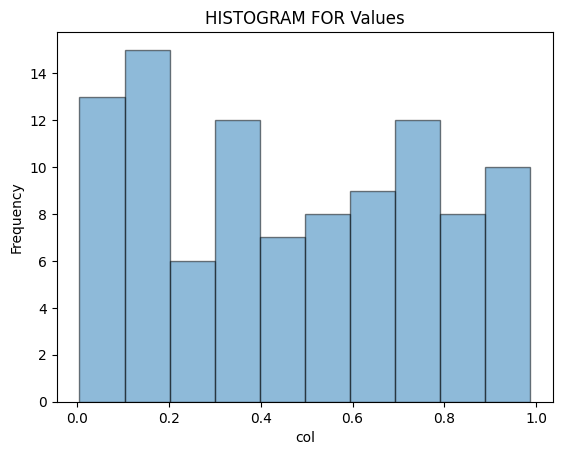

In [47]:
num_col=df.select_dtypes(include=['int','float']).columns
for col in num_col:
    df[col].hist(bins=10, alpha=0.5, edgecolor='black',grid=False)
    plt.title(f"HISTOGRAM FOR {col}")
    plt.ylabel('Frequency')
    plt.xlabel('col')
    plt.show()

In [48]:
l_df = df[df["Labels"].notna()]
xt=l_df[["Values"]]
yt=l_df["Labels"]

In [49]:
ul_df = df[df["Labels"].isna()]
x_te=ul_df[["Values"]]

In [50]:
t_label=["Class 1" if x<=0.5 else "Class 2" for x in val[50:]]

In [51]:
k_val=[1,2,3,4,5,20,30]
results={}
accuracies={}

In [52]:
for k in k_val:
    knn= KNeighborsClassifier(n_neighbors=k)
    knn.fit(xt,yt)
    pred=knn.predict(x_te)
    results[k]=pred

    acc= accuracy_score(t_label,pred)*100
    accuracies[k]=acc
    print(f"ACCURACY FOR K={k} {acc:.2f}%")

    ul_df.loc[:,f"Label_k{k}"]=pred

ACCURACY FOR K=1 100.00%
ACCURACY FOR K=2 100.00%
ACCURACY FOR K=3 98.00%
ACCURACY FOR K=4 98.00%
ACCURACY FOR K=5 98.00%
ACCURACY FOR K=20 98.00%
ACCURACY FOR K=30 100.00%


In [53]:
print(pred)

['Class 2' 'Class 2' 'Class 2' 'Class 2' 'Class 2' 'Class 2' 'Class 1'
 'Class 1' 'Class 1' 'Class 1' 'Class 1' 'Class 1' 'Class 2' 'Class 1'
 'Class 1' 'Class 2' 'Class 1' 'Class 2' 'Class 1' 'Class 2' 'Class 2'
 'Class 1' 'Class 1' 'Class 2' 'Class 2' 'Class 2' 'Class 2' 'Class 1'
 'Class 1' 'Class 1' 'Class 2' 'Class 2' 'Class 1' 'Class 1' 'Class 1'
 'Class 1' 'Class 2' 'Class 2' 'Class 2' 'Class 1' 'Class 1' 'Class 2'
 'Class 2' 'Class 2' 'Class 2' 'Class 1' 'Class 2' 'Class 1' 'Class 1'
 'Class 1']


In [54]:
print(ul_df)

   Point    Values Labels Label_k1 Label_k2 Label_k3 Label_k4 Label_k5  \
50   x51  0.969585    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
51   x52  0.775133    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
52   x53  0.939499    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
53   x54  0.894827    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
54   x55  0.597900    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
55   x56  0.921874    NaN  Class 2  Class 2  Class 2  Class 2  Class 2   
56   x57  0.088493    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
57   x58  0.195983    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
58   x59  0.045227    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
59   x60  0.325330    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
60   x61  0.388677    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
61   x62  0.271349    NaN  Class 1  Class 1  Class 1  Class 1  Class 1   
62   x63  0.828738    NaN  Class 2  Cl

In [55]:
df1= ul_df.drop(columns=['Labels'],axis=0)
print(df1)

   Point    Values Label_k1 Label_k2 Label_k3 Label_k4 Label_k5 Label_k20  \
50   x51  0.969585  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
51   x52  0.775133  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
52   x53  0.939499  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
53   x54  0.894827  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
54   x55  0.597900  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
55   x56  0.921874  Class 2  Class 2  Class 2  Class 2  Class 2   Class 2   
56   x57  0.088493  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   
57   x58  0.195983  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   
58   x59  0.045227  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   
59   x60  0.325330  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   
60   x61  0.388677  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   
61   x62  0.271349  Class 1  Class 1  Class 1  Class 1  Class 1   Class 1   

In [56]:
print("\n ACCURACIES FOR DIFFERENT K VALUES:")
for k, acc in accuracies.items():
    print(f"k={k}: {acc:.2f}%")


 ACCURACIES FOR DIFFERENT K VALUES:
k=1: 100.00%
k=2: 100.00%
k=3: 98.00%
k=4: 98.00%
k=5: 98.00%
k=20: 98.00%
k=30: 100.00%
